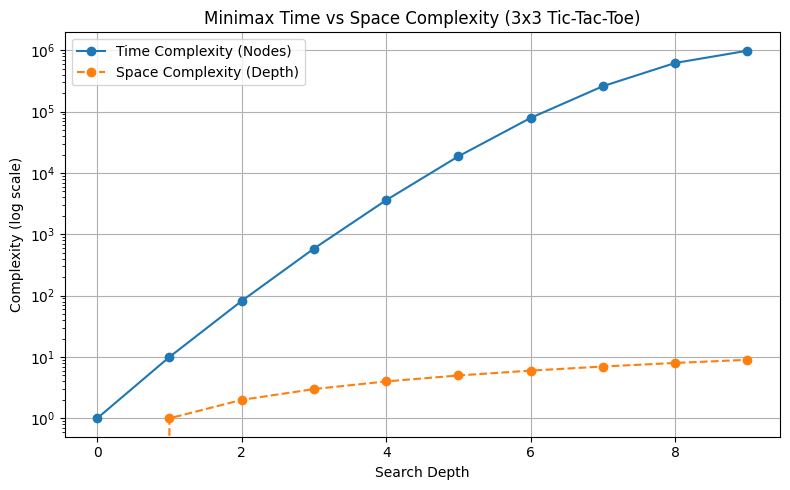

In [7]:
import matplotlib.pyplot as plt
import math

# 3x3 board → 9 cells
cells = 9

# Time Complexity (Nodes)

def exact_nodes(cells, depth):
    result = 1
    for i in range(depth):
        result *= (cells - i)
    return result

def cumulative_nodes(cells, max_depth):
    totals = []
    running = 0
    for d in range(max_depth + 1):
        running += exact_nodes(cells, d)
        totals.append(running)
    return totals

# Space complexity = recursion depth = O(d)

def space_complexity(depths):
    return depths  # linear growth

depths = list(range(0, 10))   # 0 to 9 (3x3 max depth = 9)

time_nodes = cumulative_nodes(cells, 9)
space_nodes = space_complexity(depths)


plt.figure(figsize=(8, 5))

# Time Complexity
plt.plot(depths, time_nodes, marker='o', label='Time Complexity (Nodes)')

# Space Complexity
plt.plot(depths, space_nodes, marker='o', linestyle='--', label='Space Complexity (Depth)')

plt.yscale("log")  # exponential vs linear

plt.xlabel("Search Depth")
plt.ylabel("Complexity (log scale)")
plt.title("Minimax Time vs Space Complexity (3x3 Tic-Tac-Toe)")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

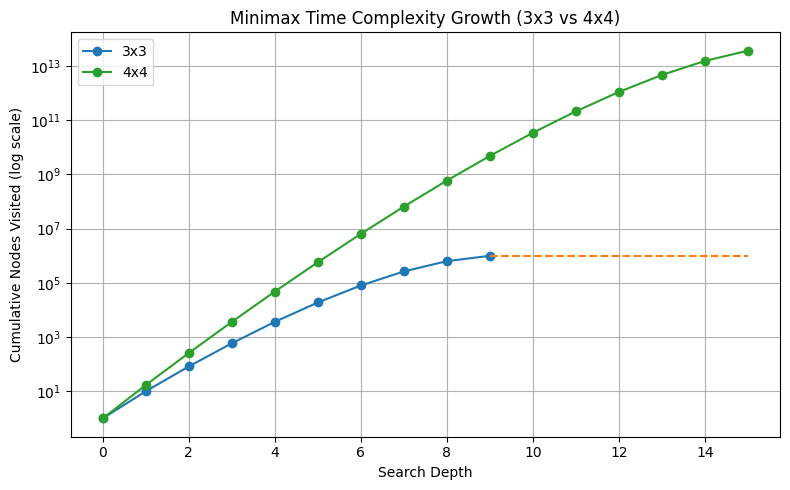

In [10]:
import matplotlib.pyplot as plt

# Calculate exact number of nodes at one depth
def exact_nodes(cells, depth):
    result = 1
    for i in range(depth):
        result *= (cells - i)
    return result

# Calculate cumulative number of nodes up to max_depth
def cumulative_nodes(cells, max_depth):
    totals = []
    running = 0
    for d in range(max_depth + 1):
        running += exact_nodes(cells, d)
        totals.append(running)
    return totals

# X-axis from 0 to 15
depths = list(range(0, 16))

# Data
nodes_3x3 = cumulative_nodes(9, 15)
nodes_4x4 = cumulative_nodes(16, 15)

plt.figure(figsize=(8, 5))

# ---- 3x3 split ----
cutoff = 9

# solid (0–9)
plt.plot(depths[:cutoff+1], nodes_3x3[:cutoff+1],
         marker='o', label='3x3')

# dashed (9–15)
plt.plot(depths[cutoff:], nodes_3x3[cutoff:],
         linestyle='--')

# ---- 4x4 normal ----
plt.plot(depths, nodes_4x4, marker='o', label='4x4')

# Log scale
plt.yscale("log")

plt.xlabel("Search Depth")
plt.ylabel("Cumulative Nodes Visited (log scale)")
plt.title("Minimax Time Complexity Growth (3x3 vs 4x4)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

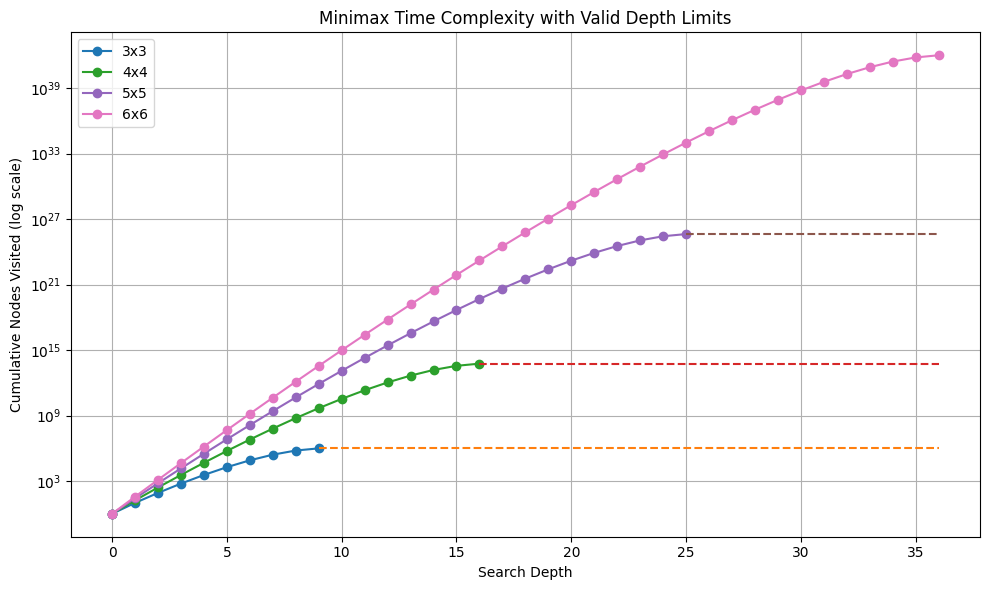

In [9]:
import matplotlib.pyplot as plt

# Calculate exact number of nodes at one depth
def exact_nodes(cells, depth):
    result = 1
    for i in range(depth):
        result *= (cells - i)
    return result

# Calculate cumulative number of nodes up to max_depth
def cumulative_nodes(cells, max_depth):
    totals = []
    running = 0
    for d in range(max_depth + 1):
        running += exact_nodes(cells, d)
        totals.append(running)
    return totals


# X-axis from 0 to 36
depths = list(range(0, 37))

# Compute all
nodes_3x3 = cumulative_nodes(9, 36)
nodes_4x4 = cumulative_nodes(16, 36)
nodes_5x5 = cumulative_nodes(25, 36)
nodes_6x6 = cumulative_nodes(36, 36)


# Helper function to split solid / dashed
def plot_with_cutoff(depths, nodes, cutoff, label):
    # solid part (valid region)
    solid_x = depths[:cutoff + 1]
    solid_y = nodes[:cutoff + 1]

    # dashed part (invalid region)
    dashed_x = depths[cutoff:]
    dashed_y = nodes[cutoff:]

    plt.plot(solid_x, solid_y, marker='o', label=label)
    plt.plot(dashed_x, dashed_y, linestyle='--')


# Plot
plt.figure(figsize=(10, 6))

plot_with_cutoff(depths, nodes_3x3, 9,  "3x3")
plot_with_cutoff(depths, nodes_4x4, 16, "4x4")
plot_with_cutoff(depths, nodes_5x5, 25, "5x5")
plot_with_cutoff(depths, nodes_6x6, 36, "6x6")

# Log scale
plt.yscale("log")

plt.xlabel("Search Depth")
plt.ylabel("Cumulative Nodes Visited (log scale)")
plt.title("Minimax Time Complexity with Valid Depth Limits")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

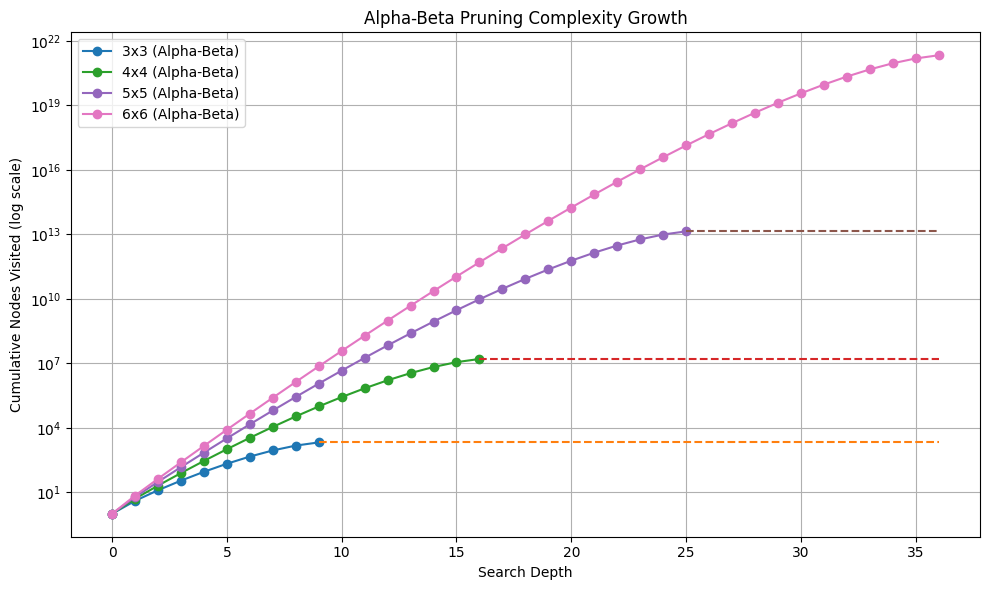

In [12]:
import matplotlib.pyplot as plt
import math

# Approximate alpha-beta pruning nodes
# Using best-case idea: O(b^(d/2)) → sqrt of minimax nodes
def exact_nodes(cells, depth):
    result = 1
    for i in range(depth):
        result *= (cells - i)
    return result

def cumulative_alpha_beta_nodes(cells, max_depth):
    totals = []
    running = 0
    for d in range(max_depth + 1):
        ab_nodes = math.sqrt(exact_nodes(cells, d))  # approximation
        running += ab_nodes
        totals.append(running)
    return totals


# X-axis from 0 to 36
depths = list(range(0, 37))

# Alpha-Beta only
ab_3x3 = cumulative_alpha_beta_nodes(9, 36)
ab_4x4 = cumulative_alpha_beta_nodes(16, 36)
ab_5x5 = cumulative_alpha_beta_nodes(25, 36)
ab_6x6 = cumulative_alpha_beta_nodes(36, 36)


# Plot helper (solid + dashed after cutoff)
def plot_ab(depths, nodes, cutoff, label):
    # valid
    plt.plot(depths[:cutoff+1], nodes[:cutoff+1],
             marker='o', label=label)

    # beyond valid depth (dashed)
    plt.plot(depths[cutoff:], nodes[cutoff:],
             linestyle='--')


# Plot
plt.figure(figsize=(10, 6))

plot_ab(depths, ab_3x3, 9,  "3x3 (Alpha-Beta)")
plot_ab(depths, ab_4x4, 16, "4x4 (Alpha-Beta)")
plot_ab(depths, ab_5x5, 25, "5x5 (Alpha-Beta)")
plot_ab(depths, ab_6x6, 36, "6x6 (Alpha-Beta)")

plt.yscale("log")

plt.xlabel("Search Depth")
plt.ylabel("Cumulative Nodes Visited (log scale)")
plt.title("Alpha-Beta Pruning Complexity Growth")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

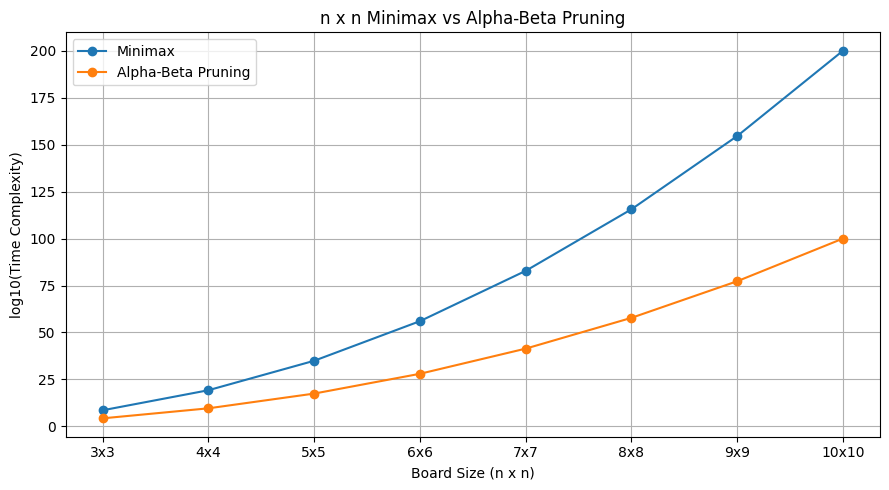

In [13]:
import matplotlib.pyplot as plt
import math

# Compute log10 of minimax and alpha-beta complexity
def minimax_log_complexity(n):
    cells = n * n
    # log10((n^2)^(n^2)) = (n^2) * log10(n^2)
    return cells * math.log10(cells)

def alphabeta_log_complexity(n):
    cells = n * n
    # log10((n^2)^((n^2)/2)) = (n^2 / 2) * log10(n^2)
    return (cells / 2) * math.log10(cells)

# Choose board sizes
n_values = list(range(3, 11))   # 3x3 up to 10x10

# Calculate values
minimax_values = [minimax_log_complexity(n) for n in n_values]
alphabeta_values = [alphabeta_log_complexity(n) for n in n_values]

# Create labels like 3x3, 4x4, ...
labels = [f"{n}x{n}" for n in n_values]

# Plot
plt.figure(figsize=(9, 5))
plt.plot(labels, minimax_values, marker='o', label='Minimax')
plt.plot(labels, alphabeta_values, marker='o', label='Alpha-Beta Pruning')

plt.xlabel("Board Size (n x n)")
plt.ylabel("log10(Time Complexity)")
plt.title("n x n Minimax vs Alpha-Beta Pruning")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

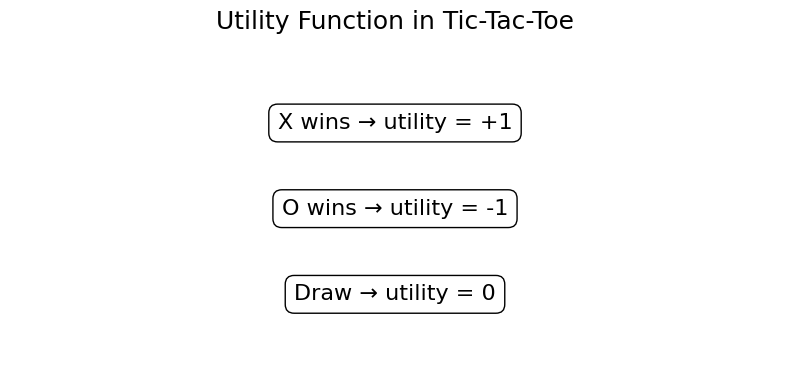

In [14]:
import matplotlib.pyplot as plt

# Create figure
plt.figure(figsize=(8, 4))
plt.axis('off')

# Add text boxes
plt.text(
    0.5, 0.75,
    "X wins → utility = +1",
    fontsize=16,
    ha='center',
    va='center',
    bbox=dict(boxstyle="round,pad=0.4", edgecolor="black", facecolor="white")
)

plt.text(
    0.5, 0.50,
    "O wins → utility = -1",
    fontsize=16,
    ha='center',
    va='center',
    bbox=dict(boxstyle="round,pad=0.4", edgecolor="black", facecolor="white")
)

plt.text(
    0.5, 0.25,
    "Draw → utility = 0",
    fontsize=16,
    ha='center',
    va='center',
    bbox=dict(boxstyle="round,pad=0.4", edgecolor="black", facecolor="white")
)

plt.title("Utility Function in Tic-Tac-Toe", fontsize=18)
plt.tight_layout()
plt.show()

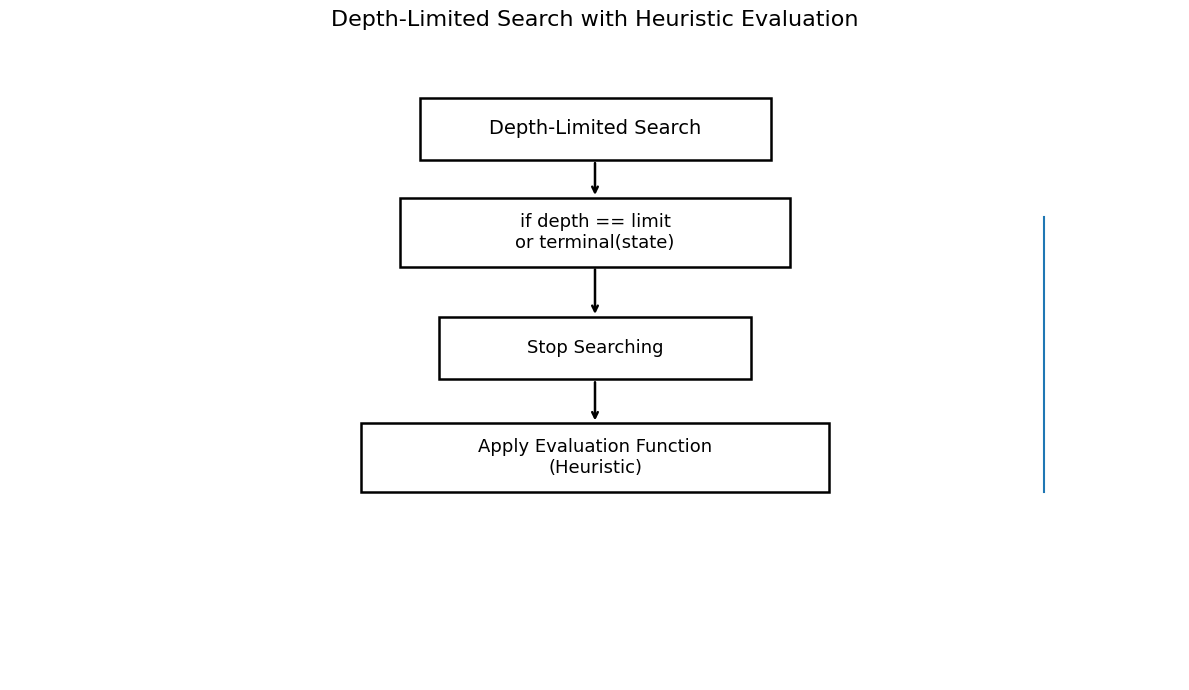

In [17]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# Create figure
fig, ax = plt.subplots(figsize=(12, 7))
ax.set_xlim(0, 12)
ax.set_ylim(0, 10)
ax.axis("off")

# ---------- Helper function ----------
def add_box(x, y, w, h, text, fontsize=12):
    box = Rectangle((x, y), w, h, fill=False, linewidth=1.8)
    ax.add_patch(box)
    ax.text(x + w/2, y + h/2, text, ha='center', va='center', fontsize=fontsize)

# ---------- Flowchart part ----------
add_box(4.2, 8.3, 3.6, 1.0, "Depth-Limited Search", fontsize=14)
add_box(4.0, 6.6, 4.0, 1.1, "if depth == limit\nor terminal(state)", fontsize=13)
add_box(4.4, 4.8, 3.2, 1.0, "Stop Searching", fontsize=13)
add_box(3.6, 3.0, 4.8, 1.1, "Apply Evaluation Function\n(Heuristic)", fontsize=13)

# Arrows
ax.annotate("", xy=(6, 7.7), xytext=(6, 8.3), arrowprops=dict(arrowstyle="->", linewidth=1.8))
ax.annotate("", xy=(6, 5.8), xytext=(6, 6.6), arrowprops=dict(arrowstyle="->", linewidth=1.8))
ax.annotate("", xy=(6, 4.1), xytext=(6, 4.8), arrowprops=dict(arrowstyle="->", linewidth=1.8))



# Zero line for heuristic chart
ax.plot([10.6, 10.6], [3.0, 7.4], linewidth=1.5)

# Title
plt.title("Depth-Limited Search with Heuristic Evaluation", fontsize=16, pad=20)

# Save and show
plt.tight_layout()
plt.savefig("depth_limited_search_heuristic.png", dpi=300, bbox_inches="tight")
plt.show()

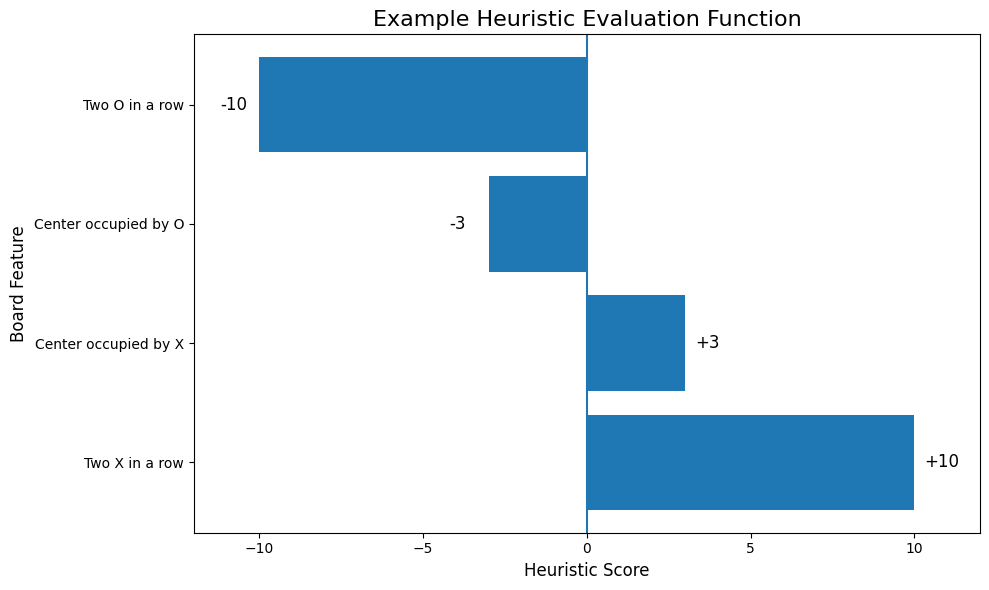

In [16]:
import matplotlib.pyplot as plt

# Heuristic rules and scores
features = [
    "Two X in a row",
    "Center occupied by X",
    "Center occupied by O",
    "Two O in a row"
]
scores = [10, 3, -3, -10]

# Create figure
plt.figure(figsize=(10, 6))

# Horizontal bar chart
bars = plt.barh(features, scores)

# Zero line
plt.axvline(0, linewidth=1.5)

# Add value labels
for i, score in enumerate(scores):
    if score > 0:
        plt.text(score + 0.3, i, f"+{score}", va='center', fontsize=12)
    else:
        plt.text(score - 1.2, i, f"{score}", va='center', fontsize=12)

# Titles and labels
plt.title("Example Heuristic Evaluation Function", fontsize=16)
plt.xlabel("Heuristic Score", fontsize=12)
plt.ylabel("Board Feature", fontsize=12)

# Make layout cleaner
plt.xlim(-12, 12)
plt.tight_layout()

# Save image
plt.savefig("heuristic_evaluation_clean.png", dpi=300, bbox_inches="tight")

# Show image
plt.show()

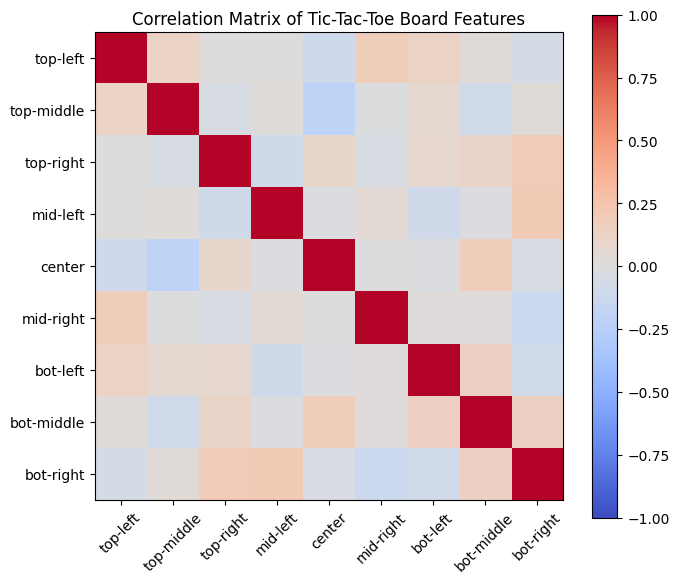

In [20]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)
data = np.random.choice([1, -1, 0], size=(100, 9))

labels = [
    "top-left", "top-middle", "top-right",
    "mid-left", "center", "mid-right",
    "bot-left", "bot-middle", "bot-right"
]

corr = np.corrcoef(data, rowvar=False)

plt.figure(figsize=(7, 6))

# softer color
plt.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)

plt.colorbar()

plt.xticks(range(9), labels, rotation=45)
plt.yticks(range(9), labels)

plt.title("Correlation Matrix of Tic-Tac-Toe Board Features")

plt.tight_layout()
plt.savefig("correlation_matrix_soft.png", dpi=300)
plt.show()

Epoch  1/20 | Train Accuracy: 0.6867 | Validation Accuracy: 0.8000
Epoch  2/20 | Train Accuracy: 0.8340 | Validation Accuracy: 0.8510
Epoch  3/20 | Train Accuracy: 0.8495 | Validation Accuracy: 0.8570
Epoch  4/20 | Train Accuracy: 0.8518 | Validation Accuracy: 0.8570
Epoch  5/20 | Train Accuracy: 0.8525 | Validation Accuracy: 0.8570
Epoch  6/20 | Train Accuracy: 0.8538 | Validation Accuracy: 0.8570
Epoch  7/20 | Train Accuracy: 0.8532 | Validation Accuracy: 0.8590
Epoch  8/20 | Train Accuracy: 0.8558 | Validation Accuracy: 0.8590
Epoch  9/20 | Train Accuracy: 0.8572 | Validation Accuracy: 0.8610
Epoch 10/20 | Train Accuracy: 0.8585 | Validation Accuracy: 0.8600
Epoch 11/20 | Train Accuracy: 0.8602 | Validation Accuracy: 0.8660
Epoch 12/20 | Train Accuracy: 0.8605 | Validation Accuracy: 0.8670
Epoch 13/20 | Train Accuracy: 0.8635 | Validation Accuracy: 0.8670
Epoch 14/20 | Train Accuracy: 0.8622 | Validation Accuracy: 0.8650
Epoch 15/20 | Train Accuracy: 0.8640 | Validation Accuracy: 0.

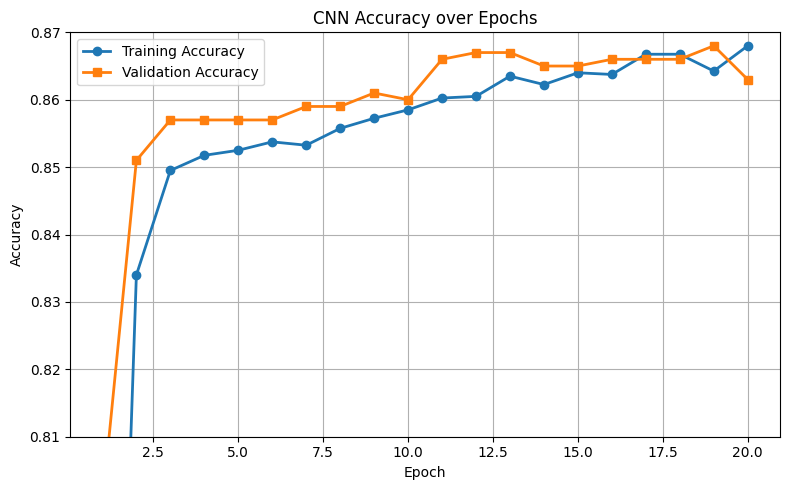

In [25]:
import random
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader, random_split

# ----------------------------
# 1. Reproducibility
# ----------------------------
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

# ----------------------------
# 2. Generate Tic-Tac-Toe boards
# ----------------------------
# X = 1, O = -1, empty = 0
# Label:
#   1 = good for X
#   0 = not good for X
#
# Simple rule-based label:
#   + Two X in a row: +10
#   + Center occupied by X: +3
#   - Two O in a row: -10
#   - Center occupied by O: -3
# If final score > 0 => label 1, else 0

WIN_LINES = [
    [0, 1, 2], [3, 4, 5], [6, 7, 8],   # rows
    [0, 3, 6], [1, 4, 7], [2, 5, 8],   # cols
    [0, 4, 8], [2, 4, 6]               # diagonals
]

def heuristic_score(board):
    score = 0

    # center
    if board[4] == 1:
        score += 3
    elif board[4] == -1:
        score -= 3

    # two-in-a-row patterns
    for line in WIN_LINES:
        values = [board[i] for i in line]

        # Two X and one empty
        if values.count(1) == 2 and values.count(0) == 1:
            score += 10

        # Two O and one empty
        if values.count(-1) == 2 and values.count(0) == 1:
            score -= 10

    return score

def generate_random_board():
    board = [0] * 9

    # random number of placed marks
    moves = random.randint(0, 9)

    # keep board somewhat legal
    x_count = 0
    o_count = 0
    positions = random.sample(range(9), moves)

    for pos in positions:
        if x_count <= o_count:
            board[pos] = 1
            x_count += 1
        else:
            board[pos] = -1
            o_count += 1

    return board

def create_dataset(num_samples=5000):
    X = []
    y = []

    for _ in range(num_samples):
        board = generate_random_board()
        score = heuristic_score(board)
        label = 1 if score > 0 else 0

        # reshape to 1x3x3 for CNN
        X.append(np.array(board, dtype=np.float32).reshape(1, 3, 3))
        y.append(label)

    X = np.array(X, dtype=np.float32)
    y = np.array(y, dtype=np.int64)

    return X, y

# ----------------------------
# 3. CNN model
# ----------------------------
class SmallCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=8, kernel_size=2)
        self.relu = nn.ReLU()
        self.fc1 = nn.Linear(8 * 2 * 2, 16)
        self.fc2 = nn.Linear(16, 2)

    def forward(self, x):
        x = self.conv1(x)         # [batch, 8, 2, 2]
        x = self.relu(x)
        x = x.view(x.size(0), -1) # flatten
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x

# ----------------------------
# 4. Prepare data
# ----------------------------
X, y = create_dataset(num_samples=5000)

X_tensor = torch.tensor(X)
y_tensor = torch.tensor(y)

dataset = TensorDataset(X_tensor, y_tensor)

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

# ----------------------------
# 5. Train model
# ----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = SmallCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

num_epochs = 20

train_accuracies = []
val_accuracies = []

for epoch in range(num_epochs):
    # ----- Training -----
    model.train()
    train_correct = 0
    train_total = 0

    for inputs, labels in train_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        _, predicted = torch.max(outputs, 1)
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()

    train_acc = train_correct / train_total
    train_accuracies.append(train_acc)

    # ----- Validation -----
    model.eval()
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)

            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_acc = val_correct / val_total
    val_accuracies.append(val_acc)

    print(f"Epoch {epoch+1:2d}/{num_epochs} | "
          f"Train Accuracy: {train_acc:.4f} | "
          f"Validation Accuracy: {val_acc:.4f}")

# ----------------------------
# 6. Plot accuracy curve
# ----------------------------
epochs = list(range(1, num_epochs + 1))

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_accuracies, marker='o', linewidth=2, label='Training Accuracy')
plt.plot(epochs, val_accuracies, marker='s', linewidth=2, label='Validation Accuracy')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN Accuracy over Epochs")
plt.ylim(0.81, 0.87)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("cnn_accuracy_over_epochs.png", dpi=300, bbox_inches="tight")
plt.show()

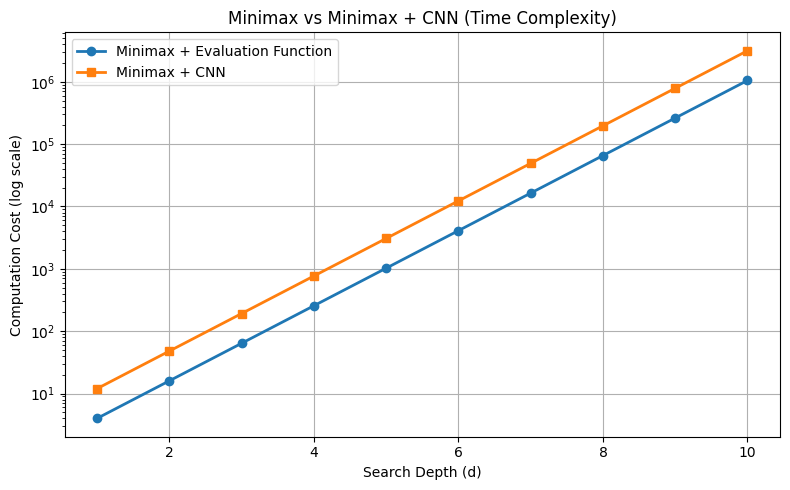

In [26]:
import matplotlib.pyplot as plt
import numpy as np

# Search depth
depths = np.arange(1, 11)

# Branching factor (example)
b = 4

# Time complexity ~ b^d
minimax_eval = b ** depths

# CNN version: same complexity, but higher constant cost
cnn_eval = 3 * (b ** depths)   # CNN is slower per node

# Plot
plt.figure(figsize=(8, 5))

plt.plot(depths, minimax_eval, marker='o', linewidth=2,
         label='Minimax + Evaluation Function')

plt.plot(depths, cnn_eval, marker='s', linewidth=2,
         label='Minimax + CNN')

# Log scale (important for exponential)
plt.yscale('log')

plt.xlabel("Search Depth (d)")
plt.ylabel("Computation Cost (log scale)")
plt.title("Minimax vs Minimax + CNN (Time Complexity)")

plt.grid(True)
plt.legend()
plt.tight_layout()

plt.savefig("minimax_vs_cnn.png", dpi=300)
plt.show()

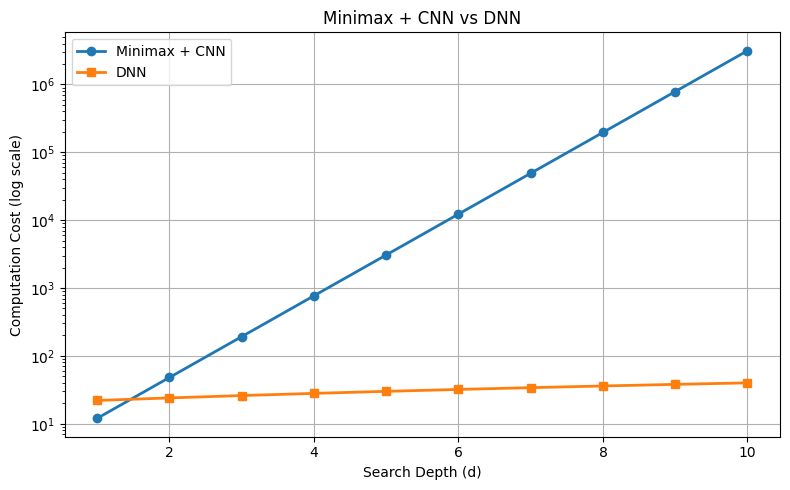

In [27]:
import matplotlib.pyplot as plt
import numpy as np

# Search depth
depths = np.arange(1, 11)

# Example branching factor
b = 4

# Minimax + CNN:
# still depends on the search tree, so complexity is still exponential
minimax_cnn = 3 * (b ** depths)   # constant 3 means CNN evaluation is more expensive per node

# DNN:
# direct prediction, no search tree
# here we use a much slower growth just to show the idea
dnn = 20 + 2 * depths

# Plot
plt.figure(figsize=(8, 5))

plt.plot(depths, minimax_cnn, marker='o', linewidth=2, label='Minimax + CNN')
plt.plot(depths, dnn, marker='s', linewidth=2, label='DNN')

# Log scale so exponential growth is easier to compare
plt.yscale('log')

plt.xlabel("Search Depth (d)")
plt.ylabel("Computation Cost (log scale)")
plt.title("Minimax + CNN vs DNN")
plt.grid(True)
plt.legend()
plt.tight_layout()

plt.savefig("minimax_cnn_vs_dnn.png", dpi=300)
plt.show()

3x3 | quality=0.500 | avg move time=0.0373s
4x4 | quality=0.500 | avg move time=0.0153s
5x5 | quality=0.500 | avg move time=0.0031s
6x6 | quality=0.500 | avg move time=0.0091s


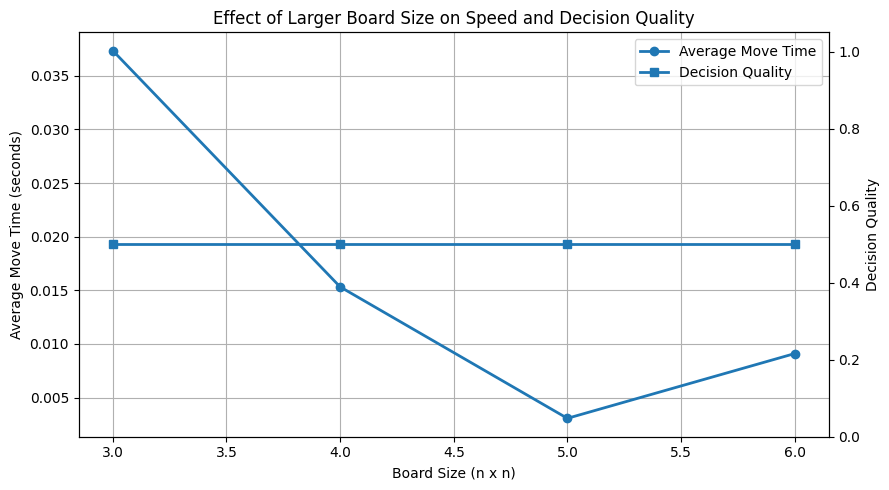

In [29]:
import time
import math
import random
import matplotlib.pyplot as plt

# =========================
# Basic Tic-Tac-Toe helpers
# =========================

def create_board(n):
    return [[" " for _ in range(n)] for _ in range(n)]

def available_moves(board):
    moves = []
    n = len(board)
    for i in range(n):
        for j in range(n):
            if board[i][j] == " ":
                moves.append((i, j))
    return moves

def is_full(board):
    for row in board:
        for cell in row:
            if cell == " ":
                return False
    return True

def check_winner(board):
    n = len(board)

    # rows
    for i in range(n):
        first = board[i][0]
        if first != " " and all(board[i][j] == first for j in range(n)):
            return first

    # cols
    for j in range(n):
        first = board[0][j]
        if first != " " and all(board[i][j] == first for i in range(n)):
            return first

    # main diagonal
    first = board[0][0]
    if first != " " and all(board[i][i] == first for i in range(n)):
        return first

    # anti-diagonal
    first = board[0][n - 1]
    if first != " " and all(board[i][n - 1 - i] == first for i in range(n)):
        return first

    return None

def terminal(board):
    return check_winner(board) is not None or is_full(board)

# =========================
# Heuristic evaluation
# =========================

def evaluate(board, player):
    """
    Positive score = good for player
    Negative score = good for opponent
    """
    n = len(board)
    opponent = "O" if player == "X" else "X"
    winner = check_winner(board)

    if winner == player:
        return 100000
    if winner == opponent:
        return -100000
    if is_full(board):
        return 0

    score = 0

    lines = []

    # rows
    for i in range(n):
        lines.append([board[i][j] for j in range(n)])

    # cols
    for j in range(n):
        lines.append([board[i][j] for i in range(n)])

    # diagonals
    lines.append([board[i][i] for i in range(n)])
    lines.append([board[i][n - 1 - i] for i in range(n)])

    for line in lines:
        p_count = line.count(player)
        o_count = line.count(opponent)
        empty = line.count(" ")

        # only player occupies line
        if o_count == 0:
            score += p_count * p_count

        # only opponent occupies line
        if p_count == 0:
            score -= o_count * o_count

        # almost winning line
        if p_count == n - 1 and empty == 1:
            score += 50
        if o_count == n - 1 and empty == 1:
            score -= 50

    # center preference
    if n % 2 == 1:
        c = n // 2
        if board[c][c] == player:
            score += 3
        elif board[c][c] == opponent:
            score -= 3

    return score

# =========================
# Depth-limited minimax
# =========================

def minimax(board, depth, maximizing, player, root_player):
    opponent = "O" if player == "X" else "X"

    if depth == 0 or terminal(board):
        return evaluate(board, root_player)

    moves = available_moves(board)

    if maximizing:
        best = -math.inf
        for i, j in moves:
            board[i][j] = player
            value = minimax(board, depth - 1, False, opponent, root_player)
            board[i][j] = " "
            if value > best:
                best = value
        return best
    else:
        best = math.inf
        for i, j in moves:
            board[i][j] = player
            value = minimax(board, depth - 1, True, opponent, root_player)
            board[i][j] = " "
            if value < best:
                best = value
        return best

def best_move(board, player, depth):
    opponent = "O" if player == "X" else "X"
    moves = available_moves(board)

    best_score = -math.inf
    best = None

    start = time.perf_counter()

    for i, j in moves:
        board[i][j] = player
        score = minimax(board, depth - 1, False, opponent, player)
        board[i][j] = " "
        if score > best_score:
            best_score = score
            best = (i, j)

    elapsed = time.perf_counter() - start
    return best, elapsed

# =========================
# Play one game
# =========================

def play_game(n, shallow_depth, deep_depth):
    board = create_board(n)

    # X = shallow agent
    # O = deeper reference agent
    current = "X"

    shallow_times = []

    while not terminal(board):
        if current == "X":
            move, elapsed = best_move(board, "X", shallow_depth)
            shallow_times.append(elapsed)
        else:
            move, _ = best_move(board, "O", deep_depth)

        if move is None:
            break

        i, j = move
        board[i][j] = current
        current = "O" if current == "X" else "X"

    winner = check_winner(board)

    # Quality score for shallow agent
    if winner == "X":
        quality = 1.0
    elif winner == "O":
        quality = 0.0
    else:
        quality = 0.5

    avg_time = sum(shallow_times) / len(shallow_times) if shallow_times else 0
    return quality, avg_time

# =========================
# Run experiments
# =========================

def run_experiments():
    board_sizes = [3, 4, 5, 6]

    # shallow agent depth by board size
    shallow_depths = {
        3: 5,
        4: 3,
        5: 2,
        6: 2
    }

    # deeper reference agent
    deep_depths = {
        3: 7,
        4: 4,
        5: 3,
        6: 3
    }

    games_per_size = 5

    qualities = []
    avg_times = []

    for n in board_sizes:
        q_list = []
        t_list = []

        for _ in range(games_per_size):
            q, t = play_game(n, shallow_depths[n], deep_depths[n])
            q_list.append(q)
            t_list.append(t)

        qualities.append(sum(q_list) / len(q_list))
        avg_times.append(sum(t_list) / len(t_list))

        print(f"{n}x{n} | quality={qualities[-1]:.3f} | avg move time={avg_times[-1]:.4f}s")

    return board_sizes, qualities, avg_times

# =========================
# Plot
# =========================

board_sizes, qualities, avg_times = run_experiments()

fig, ax1 = plt.subplots(figsize=(9, 5))

# Left y-axis: time
line1 = ax1.plot(board_sizes, avg_times, marker='o', linewidth=2, label='Average Move Time')
ax1.set_xlabel("Board Size (n x n)")
ax1.set_ylabel("Average Move Time (seconds)")
ax1.grid(True)

# Right y-axis: quality
ax2 = ax1.twinx()
line2 = ax2.plot(board_sizes, qualities, marker='s', linewidth=2, label='Decision Quality')
ax2.set_ylabel("Decision Quality")
ax2.set_ylim(0, 1.05)

# Combine legends
lines = line1 + line2
labels = [line.get_label() for line in lines]
ax1.legend(lines, labels, loc='best')

plt.title("Effect of Larger Board Size on Speed and Decision Quality")
plt.tight_layout()
plt.savefig("board_size_vs_time_and_quality.png", dpi=300, bbox_inches="tight")
plt.show()

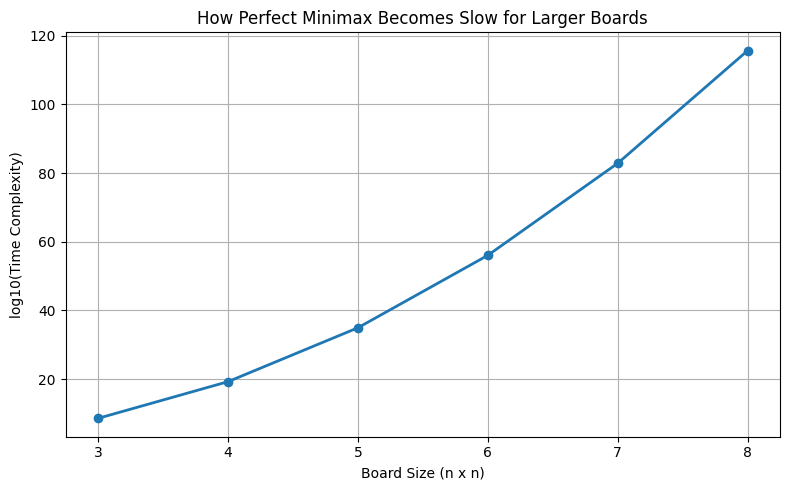

In [30]:
import matplotlib.pyplot as plt
import numpy as np
import math

# Board sizes
n_values = np.array([3, 4, 5, 6, 7, 8])

# Perfect minimax time complexity approximation:
# T = O(b^m), where b ≈ n^2 and m ≈ n^2
# So we use (n^2)^(n^2)
# To make the graph readable, take log10
log_time_complexity = []

for n in n_values:
    cells = n * n
    value = cells * math.log10(cells)   # log10((n^2)^(n^2))
    log_time_complexity.append(value)

# Plot
plt.figure(figsize=(8, 5))
plt.plot(n_values, log_time_complexity, marker='o', linewidth=2)

plt.xlabel("Board Size (n x n)")
plt.ylabel("log10(Time Complexity)")
plt.title("How Perfect Minimax Becomes Slow for Larger Boards")
plt.grid(True)
plt.tight_layout()

plt.savefig("perfect_minimax_slow.png", dpi=300, bbox_inches="tight")
plt.show()

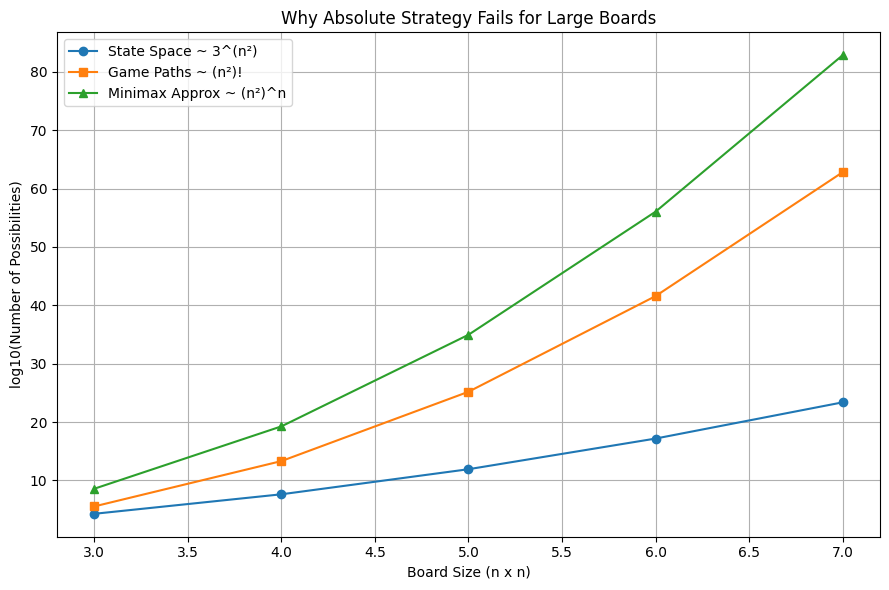

In [32]:
import matplotlib.pyplot as plt
import numpy as np
import math

# Board sizes
n_values = np.array([3, 4, 5, 6, 7])

log_states = []
log_paths = []
log_minimax = []

for n in n_values:
    cells = n * n

    # 1. State space: 3^(n^2)
    state = cells * math.log10(3)
    log_states.append(state)

    # 2. Game paths: (n^2)!
    path = math.log10(math.factorial(cells))
    log_paths.append(path)

    # 3. Minimax approximation: (n^2)^n
    minimax = cells * math.log10(cells)
    log_minimax.append(minimax)

# Plot
plt.figure(figsize=(9, 6))

plt.plot(n_values, log_states, marker='o', label='State Space ~ 3^(n²)')
plt.plot(n_values, log_paths, marker='s', label='Game Paths ~ (n²)!')
plt.plot(n_values, log_minimax, marker='^', label='Minimax Approx ~ (n²)^n')

plt.xlabel("Board Size (n x n)")
plt.ylabel("log10(Number of Possibilities)")
plt.title("Why Absolute Strategy Fails for Large Boards")

plt.grid(True)
plt.legend()
plt.tight_layout()

plt.savefig("absolute_strategy_detailed.png", dpi=300)
plt.show()


Running 3x3
Shallow depth   = 4
Reference depth = 5
States          = 30
State  1: shallow=(1, 1), ref=(1, 1), time=0.0059s
State  2: shallow=(0, 0), ref=(0, 0), time=0.0002s
State  3: shallow=(1, 0), ref=(1, 0), time=0.0002s
State  4: shallow=(1, 1), ref=(0, 0), time=0.0017s
State  5: shallow=(0, 0), ref=(0, 0), time=0.0007s
State  6: shallow=(2, 2), ref=(2, 2), time=0.0015s
State  7: shallow=(0, 1), ref=(0, 1), time=0.0043s
State  8: shallow=(0, 1), ref=(0, 1), time=0.0018s
State  9: shallow=(1, 1), ref=(1, 1), time=0.0001s
State 10: shallow=(0, 1), ref=(0, 1), time=0.0001s
State 11: shallow=(0, 1), ref=(0, 1), time=0.0001s
State 12: shallow=(0, 2), ref=(0, 2), time=0.0015s
State 13: shallow=(0, 0), ref=(0, 0), time=0.0003s
State 14: shallow=(1, 1), ref=(1, 1), time=0.0060s
State 15: shallow=(1, 1), ref=(1, 1), time=0.0056s
State 16: shallow=(0, 2), ref=(0, 2), time=0.0001s
State 17: shallow=(0, 2), ref=(0, 1), time=0.0058s
State 18: shallow=(0, 2), ref=(0, 2), time=0.0029s
State 19

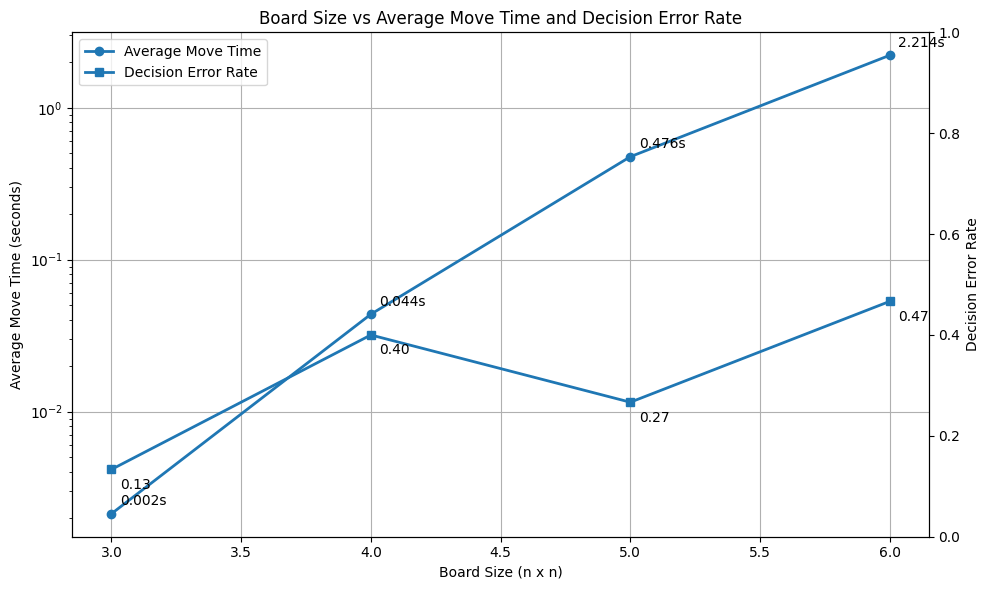

In [37]:
import time
import math
import random
import matplotlib.pyplot as plt

# =========================
# Basic board functions
# =========================

def create_board(n):
    board = []
    for _ in range(n):
        row = []
        for _ in range(n):
            row.append(" ")
        board.append(row)
    return board


def copy_board(board):
    new_board = []
    for row in board:
        new_board.append(row[:])
    return new_board


def available_moves(board):
    moves = []
    n = len(board)

    for i in range(n):
        for j in range(n):
            if board[i][j] == " ":
                moves.append((i, j))

    return moves


def is_full(board):
    for row in board:
        for cell in row:
            if cell == " ":
                return False
    return True


def check_winner(board):
    n = len(board)

    # Rows
    for i in range(n):
        first = board[i][0]
        if first != " ":
            same = True
            for j in range(1, n):
                if board[i][j] != first:
                    same = False
                    break
            if same:
                return first

    # Columns
    for j in range(n):
        first = board[0][j]
        if first != " ":
            same = True
            for i in range(1, n):
                if board[i][j] != first:
                    same = False
                    break
            if same:
                return first

    # Main diagonal
    first = board[0][0]
    if first != " ":
        same = True
        for i in range(1, n):
            if board[i][i] != first:
                same = False
                break
        if same:
            return first

    # Anti-diagonal
    first = board[0][n - 1]
    if first != " ":
        same = True
        for i in range(1, n):
            if board[i][n - 1 - i] != first:
                same = False
                break
        if same:
            return first

    return None


def terminal(board):
    if check_winner(board) is not None:
        return True
    if is_full(board):
        return True
    return False


def next_player(board):
    x_count = 0
    o_count = 0

    for row in board:
        for cell in row:
            if cell == "X":
                x_count += 1
            elif cell == "O":
                o_count += 1

    if x_count == o_count:
        return "X"
    return "O"


# =========================
# Heuristic evaluation
# =========================

def evaluate(board, root_player):
    opponent = "O"
    if root_player == "O":
        opponent = "X"

    winner = check_winner(board)

    if winner == root_player:
        return 100000
    if winner == opponent:
        return -100000
    if is_full(board):
        return 0

    score = 0
    n = len(board)

    lines = []

    # Rows
    for i in range(n):
        line = []
        for j in range(n):
            line.append(board[i][j])
        lines.append(line)

    # Columns
    for j in range(n):
        line = []
        for i in range(n):
            line.append(board[i][j])
        lines.append(line)

    # Main diagonal
    diag1 = []
    for i in range(n):
        diag1.append(board[i][i])
    lines.append(diag1)

    # Anti-diagonal
    diag2 = []
    for i in range(n):
        diag2.append(board[i][n - 1 - i])
    lines.append(diag2)

    for line in lines:
        player_count = line.count(root_player)
        opp_count = line.count(opponent)
        empty_count = line.count(" ")

        # Only root player in this line
        if opp_count == 0:
            score += player_count * player_count

        # Only opponent in this line
        if player_count == 0:
            score -= opp_count * opp_count

        # Almost winning
        if player_count == n - 1 and empty_count == 1:
            score += 50

        if opp_count == n - 1 and empty_count == 1:
            score -= 50

    # Center preference for odd n
    if n % 2 == 1:
        c = n // 2
        if board[c][c] == root_player:
            score += 3
        elif board[c][c] == opponent:
            score -= 3

    return score


# =========================
# Depth-limited minimax
# =========================

def minimax(board, depth, maximizing, current_player, root_player):
    if depth == 0 or terminal(board):
        return evaluate(board, root_player)

    moves = available_moves(board)

    next_turn = "O"
    if current_player == "O":
        next_turn = "X"

    if maximizing:
        best_value = -math.inf

        for move in moves:
            i, j = move
            board[i][j] = current_player

            value = minimax(
                board,
                depth - 1,
                False,
                next_turn,
                root_player
            )

            board[i][j] = " "

            if value > best_value:
                best_value = value

        return best_value

    best_value = math.inf

    for move in moves:
        i, j = move
        board[i][j] = current_player

        value = minimax(
            board,
            depth - 1,
            True,
            next_turn,
            root_player
        )

        board[i][j] = " "

        if value < best_value:
            best_value = value

    return best_value


def best_move_and_time(board, player, depth):
    start = time.perf_counter()

    moves = available_moves(board)
    opponent = "O"
    if player == "O":
        opponent = "X"

    best_score = -math.inf
    best_move = None

    for move in moves:
        i, j = move
        board[i][j] = player

        score = minimax(
            board,
            depth - 1,
            False,
            opponent,
            player
        )

        board[i][j] = " "

        if score > best_score:
            best_score = score
            best_move = move

    elapsed = time.perf_counter() - start
    return best_move, best_score, elapsed


# =========================
# Random legal board generation
# =========================

def generate_random_state(n, min_fill_ratio=0.25, max_fill_ratio=0.60):
    total_cells = n * n
    min_moves = int(total_cells * min_fill_ratio)
    max_moves = int(total_cells * max_fill_ratio)

    if max_moves >= total_cells:
        max_moves = total_cells - 1

    while True:
        board = create_board(n)
        move_count = random.randint(min_moves, max_moves)
        current = "X"

        all_positions = []
        for i in range(n):
            for j in range(n):
                all_positions.append((i, j))

        random.shuffle(all_positions)

        valid = True

        for k in range(move_count):
            i, j = all_positions[k]
            board[i][j] = current

            # stop if terminal reached too early
            if terminal(board):
                valid = False
                break

            if current == "X":
                current = "O"
            else:
                current = "X"

        if not valid:
            continue

        if terminal(board):
            continue

        return board


# =========================
# Experiment
# =========================

def run_experiment():
    random.seed(42)

    board_sizes = [3, 4, 5, 6]

    #tune these to keep runtime reasonable
    shallow_depths = {
        3: 4,
        4: 4,
        5: 4,
        6: 4
    }

    reference_depths = {
        3: 5,
        4: 5,
        5: 5,
        6: 5
    }

    states_per_size = {
        3: 30,
        4: 30,
        5: 30,
        6: 30
    }

    avg_times = []
    error_rates = []

    for n in board_sizes:
        shallow_depth = shallow_depths[n]
        reference_depth = reference_depths[n]
        sample_count = states_per_size[n]

        total_time = 0.0
        error_count = 0

        print("\n===================================")
        print(f"Running {n}x{n}")
        print(f"Shallow depth   = {shallow_depth}")
        print(f"Reference depth = {reference_depth}")
        print(f"States          = {sample_count}")

        for s in range(sample_count):
            board = generate_random_state(n)
            player = next_player(board)

            shallow_move, shallow_score, shallow_time = best_move_and_time(
                copy_board(board),
                player,
                shallow_depth
            )

            ref_move, ref_score, _ = best_move_and_time(
                copy_board(board),
                player,
                reference_depth
            )

            total_time += shallow_time

            if shallow_move != ref_move:
                error_count += 1

            print(
                f"State {s+1:2d}: "
                f"shallow={shallow_move}, ref={ref_move}, "
                f"time={shallow_time:.4f}s"
            )

        avg_time = total_time / sample_count
        error_rate = error_count / sample_count

        avg_times.append(avg_time)
        error_rates.append(error_rate)

        print(f"Average move time: {avg_time:.4f}s")
        print(f"Decision error rate: {error_rate:.4f}")

    return board_sizes, avg_times, error_rates


# =========================
# Plot
# =========================

board_sizes, avg_times, error_rates = run_experiment()

fig, ax1 = plt.subplots(figsize=(10, 6))

# Line 1: Average Move Time
line1 = ax1.plot(
    board_sizes,
    avg_times,
    marker="o",
    linewidth=2,
    label="Average Move Time"
)
ax1.set_xlabel("Board Size (n x n)")
ax1.set_ylabel("Average Move Time (seconds)")
ax1.set_yscale("log")
ax1.grid(True)

# Annotate line 1
for x, y in zip(board_sizes, avg_times):
    ax1.annotate(
        f"{y:.3f}s",
        xy=(x, y),
        xytext=(6, 6),
        textcoords="offset points"
    )

# Line 2: Decision Error Rate
ax2 = ax1.twinx()
line2 = ax2.plot(
    board_sizes,
    error_rates,
    marker="s",
    linewidth=2,
    label="Decision Error Rate"
)
ax2.set_ylabel("Decision Error Rate")
ax2.set_ylim(0, 1.0)

# Annotate line 2
for x, y in zip(board_sizes, error_rates):
    ax2.annotate(
        f"{y:.2f}",
        xy=(x, y),
        xytext=(6, -14),
        textcoords="offset points"
    )

# Combined legend
lines = line1 + line2
labels = []
for line in lines:
    labels.append(line.get_label())
ax1.legend(lines, labels, loc="upper left")

plt.title("Board Size vs Average Move Time and Decision Error Rate")
plt.tight_layout()
plt.savefig("real_time_vs_error.png", dpi=300, bbox_inches="tight")
plt.show()